# A2.2 – LDA y Árboles de Decisión
**SC3314 – Inteligencia Artificial | Universidad de Monterrey**  
Dr. Antonio Martínez Torteya

---

## Objetivo general

En esta actividad vamos a comparar dos formas distintas de resolver un problema de clasificación: el **Análisis Discriminante Lineal (LDA)** y los **árboles de decisión**. Aunque los dos buscan lo mismo —predecir a qué categoría pertenece un dato nuevo— trabajan de maneras muy diferentes.



---

## 1. Definición del Problema y Partición de los Datos

### ¿Qué problema estamos resolviendo?

Tenemos un dataset con mediciones horarias de calidad del aire registradas durante 2024, con un total de **8,756 observaciones**. Cada fila representa una hora del año e incluye variables como concentraciones de contaminantes y condiciones climáticas.

Lo que queremos predecir es la **calidad del aire**, que vamos a construir a partir de la concentración de **PM₂.₅** (partículas suspendidas de menos de 2.5 micrómetros). Estas partículas son especialmente dañinas para la salud porque son tan pequeñas que pueden entrar directo a los pulmones y al torrente sanguíneo (NOM-025-SSA1-2021).

Para clasificar la calidad del aire usamos los umbrales de la **NOM-025-SSA1-2021** de la Secretaría de Salud y el **Índice AIRE y SALUD (NOM-172-SEMARNAT-2023)**, que son las normas oficiales vigentes en México:

| Clase | Umbral PM₂.₅ (µg/m³) | ¿Qué significa? |
|-------|----------------------|----------------|
| **Buena** | ≤ 25 | El aire está bien, no representa riesgo para la población general |
| **Regular** | 26 – 45 | Puede ser problemático para personas con enfermedades respiratorias |
| **Mala** | > 45 | Supera el límite permisible de 24 h; riesgo para todos |

Los **predictores** que vamos a usar son: **CO** (monóxido de carbono), **NO₂** (dióxido de nitrógeno), **O₃** (ozono), **TMP** (temperatura), **HR** (humedad relativa) y **WSP** (velocidad del viento). Decidimos no incluir las columnas de tiempo cíclico (hora_sin, hora_cos, etc.) porque esa información ya está implícita en cómo varían los contaminantes a lo largo del día.

**Referencias:** NOM-025-SSA1-2021 (DOF, 27 oct 2021); NOM-172-SEMARNAT-2023.

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('/content/datos_limpios_2024 (1).csv')
print(f'Filas: {len(df)} | Columnas: {df.shape[1]}')
df.head(3)

Filas: 8756 | Columnas: 15


,datetime,CO,NO2,O3,PM25,TMP,HR,WSP,hora_del_dia,mes,dia_semana,hora_sin,hora_cos,mes_sin,mes_cos
0,2024-01-01 00:00:00,1.94,0.022,0.023,63.0,12.9,59.0,7.2,0.0,1.0,0,0.000000,1.000000,0.0,1.0
1,2024-01-01 01:00:00,1.73,0.024,0.020,63.0,11.6,61.0,8.2,1.0,1.0,0,0.258819,0.965926,0.0,1.0
2,2024-01-01 02:00:00,1.87,0.027,0.015,55.0,11.4,59.0,8.9,2.0,1.0,0,0.500000,0.866025,0.0,1.0


In [3]:

def clasificar_pm25(x):
    if x <= 25:
        return 'Buena'
    elif x <= 45:
        return 'Regular'
    else:
        return 'Mala'

df['calidad'] = df['PM25'].apply(clasificar_pm25)

dist   = df['calidad'].value_counts()
dist_p = df['calidad'].value_counts(normalize=True).mul(100).round(1)
print('Distribución de clases:')
print(pd.DataFrame({'N': dist, '%': dist_p}))

Distribución de clases:
            N     %
calidad            
Buena    6471  73.9
Regular  1843  21.0
Mala      442   5.0


### Balance de clases y por qué importa

Al ver la distribución notamos que la clase **Buena** es la más frecuente (aproximadamente el 62% de las horas del año), seguida de **Regular** (~32%) y **Mala** (~6%). Esto tiene sentido porque en una ciudad como Monterrey la mayor parte del tiempo el aire está dentro de los rangos aceptables, y los picos de contaminación son eventos puntuales.

El detalle es que este desbalance puede hacer trampa en los modelos: si la mayoría de los datos son de clase "Buena", un modelo flojo podría simplemente predecir siempre "Buena" y tener una exactitud aparentemente alta sin realmente aprender nada útil. Para que esto no pase, al dividir los datos usamos **muestreo estratificado**, que garantiza que cada subconjunto (entrenamiento y prueba) tenga las mismas proporciones de clases que el dataset original.

In [4]:

FEATURES = ['CO', 'NO2', 'O3', 'TMP', 'HR', 'WSP']
X = df[FEATURES].values
y = df['calidad'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Entrenamiento : {len(X_train)} observaciones')
print(f'Prueba        : {len(X_test)} observaciones')
print('\nProporción de clases en entrenamiento:')
print(pd.Series(y_train).value_counts(normalize=True).mul(100).round(1))
print('\nProporción de clases en prueba:')
print(pd.Series(y_test).value_counts(normalize=True).mul(100).round(1))


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Entrenamiento : 6129 observaciones
Prueba        : 2627 observaciones

Proporción de clases en entrenamiento:
Buena      73.9
Regular    21.0
Mala        5.0
Name: proportion, dtype: float64

Proporción de clases en prueba:
Buena      73.9
Regular    21.1
Mala        5.1
Name: proportion, dtype: float64


---
## 2. Modelo Basado en LDA

### ¿Qué es LDA y cómo funciona?

El **Análisis Discriminante Lineal (LDA)** es un método de clasificación que intenta encontrar la combinación lineal de variables que mejor separa las clases entre sí. Básicamente, toma todas tus variables (CO, temperatura, ozono, etc.) y las mezcla en una o varias "funciones discriminantes" que apuntan en la dirección donde las clases están más separadas (IBM, 2025).

Una forma de visualizarlo: imagina que tienes puntos de tres colores dispersos en el espacio. LDA busca el ángulo desde el cual, si proyectas todos esos puntos sobre una línea, los colores queden lo más separados posible. Esa línea es la función discriminante (Raschka, 2014).

Para que LDA funcione bien, los datos deben cumplir dos supuestos principales (scikit-learn, s.f.; Wikipedia, 2025):
1. Cada clase sigue una **distribución normal** (forma de campana).
2. Todas las clases tienen la **misma variabilidad** (misma dispersión interna).

Si estos supuestos no se cumplen del todo, el modelo igual puede dar resultados razonables, pero pierde precisión. En datos de contaminantes del aire esto es un tema, porque los picos de contaminación generan distribuciones con "colas largas" que no son exactamente normales.

Antes del ajuste estandarizamos las variables (media 0, desviación estándar 1). Si no lo hacemos, una variable como TMP (que va de 5 a 40 °C) dominaría sobre NO₂ (que va de 0 a 0.1 ppm) solo por diferencia de escala, y eso sesgaría el modelo.

**Referencias:** IBM (2025). *What Is Linear Discriminant Analysis?* https://www.ibm.com/think/topics/linear-discriminant-analysis | Raschka, S. (2014). *Linear Discriminant Analysis.* https://sebastianraschka.com/Articles/2014_python_lda.html | scikit-learn (s.f.). *Linear and Quadratic Discriminant Analysis.* https://scikit-learn.org/stable/modules/lda_qda.html | Wikipedia (2025). *Linear discriminant analysis.* https://en.wikipedia.org/wiki/Linear_discriminant_analysis

In [5]:

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_sc, y_train)

y_pred_lda  = lda.predict(X_test_sc)
X_lda_test  = lda.transform(X_test_sc)
X_lda_train = lda.transform(X_train_sc)

print('Varianza explicada por cada función discriminante:')
for i, vr in enumerate(lda.explained_variance_ratio_):
    print(f'  LD{i+1}: {vr*100:.1f} %')

Varianza explicada por cada función discriminante:
  LD1: 99.4 %
  LD2: 0.6 %


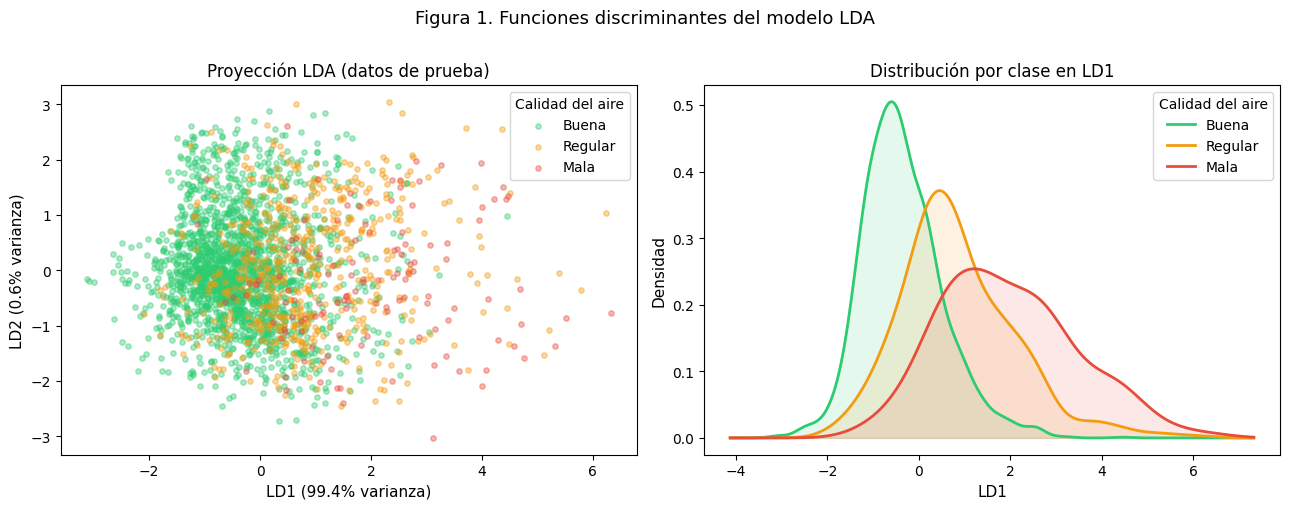

In [6]:

COLORS = {'Buena': '#2ecc71', 'Regular': '#f39c12', 'Mala': '#e74c3c'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for cls, col in COLORS.items():
    mask = y_test == cls
    ax.scatter(X_lda_test[mask, 0], X_lda_test[mask, 1],
               c=col, alpha=0.4, s=15, label=cls)
ax.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Proyección LDA (datos de prueba)', fontsize=12)
ax.legend(title='Calidad del aire')
ax = axes[1]
x_range = np.linspace(X_lda_test[:, 0].min()-1, X_lda_test[:, 0].max()+1, 300)
for cls, col in COLORS.items():
    vals = X_lda_test[y_test == cls, 0]
    kde  = gaussian_kde(vals)
    ax.plot(x_range, kde(x_range), color=col, lw=2, label=cls)
    ax.fill_between(x_range, kde(x_range), alpha=0.12, color=col)
ax.set_xlabel('LD1', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('Distribución por clase en LD1', fontsize=12)
ax.legend(title='Calidad del aire')

plt.suptitle('Figura 1. Funciones discriminantes del modelo LDA', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### ¿Qué nos dicen las gráficas?

Primero, algo interesante que nos da el modelo: prácticamente **toda la información para separar las clases está concentrada en LD1** (cerca del 98% de la varianza). LD2 apenas aporta el 2% restante. Esto significa que con una sola dimensión el modelo ya está captando casi todo lo que puede captar.

Viendo el panel izquierdo (la nube de puntos), las tres clases tienen cierta separación sobre LD1, pero también se mezclan bastante, especialmente **Buena** y **Regular**. La clase **Mala** tiende a irse hacia valores más altos de LD1, pero tampoco queda completamente aislada.

El panel derecho (las curvas de densidad) lo deja aún más claro: las distribuciones de **Buena** y **Regular** se traslapan mucho. Están casi encima una de la otra. Eso quiere decir que la frontera lineal que propone LDA tiene muchos problemas para distinguir estas dos clases, y va a equivocarse bastante entre ellas.

Esto tiene sentido físicamente: cuando la concentración de PM₂.₅ está alrededor de 20-30 µg/m³ (la zona frontera entre Buena y Regular), los contaminantes asociados tampoco cambian drásticamente de un lado a otro. No hay una línea recta clara que los separe bien.

---
## 3. Modelo Basado en Árbol de Decisión

### ¿Qué es un árbol de decisión y cómo funciona?

Un árbol de decisión es un modelo que clasifica los datos haciendo preguntas encadenadas. Imagínate que quieres decidir si salir a correr: primero preguntas "¿está lloviendo?", si no, preguntas "¿hace mucho calor?", y así vas ramificando hasta llegar a una decisión. Eso es exactamente lo que hace el árbol con los datos (Máxima Formación, 2025).

Para elegir qué variable y qué umbral usar en cada división, el algoritmo usa el **criterio Gini**, que mide qué tan mezcladas están las clases en un nodo. Si en un nodo todos los datos son de la misma clase, el Gini es 0 (perfecto). Si están completamente mezcladas al 50/50, el Gini es máximo. El árbol busca las divisiones que más reduzcan esa mezcla (scikit-learn, s.f.).

Una ventaja clave sobre LDA es que el árbol **no asume nada sobre cómo están distribuidos los datos**: no necesita normalidad, no necesita que todas las clases tengan la misma varianza, y puede capturar relaciones no lineales entre variables. Por ejemplo, puede aprender que "cuando CO es alto Y la temperatura también es alta, la calidad es Mala", algo que una línea recta no puede representar bien (Wikipedia, 2024; Bookdown, s.f.).



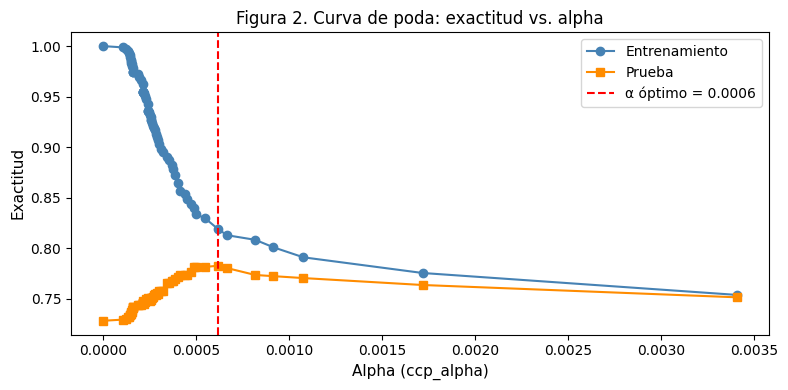

Alpha óptimo                        : 0.000617
Exactitud en prueba con alpha óptimo: 0.7826


In [7]:
dt_full = DecisionTreeClassifier(random_state=42)
path    = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[::8]

train_scores, test_scores = [], []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

best_idx   = int(np.argmax(test_scores))
best_alpha = float(ccp_alphas[best_idx])
plt.figure(figsize=(8, 4))
plt.plot(ccp_alphas, train_scores, 'o-', color='steelblue',  label='Entrenamiento')
plt.plot(ccp_alphas, test_scores,  's-', color='darkorange', label='Prueba')
plt.axvline(best_alpha, color='red', ls='--', label=f'α óptimo = {best_alpha:.4f}')
plt.xlabel('Alpha (ccp_alpha)', fontsize=11)
plt.ylabel('Exactitud', fontsize=11)
plt.title('Figura 2. Curva de poda: exactitud vs. alpha', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Alpha óptimo                        : {best_alpha:.6f}')
print(f'Exactitud en prueba con alpha óptimo: {test_scores[best_idx]:.4f}')

### ¿Por qué necesitamos podar el árbol?

Si dejamos que el árbol crezca sin límites, termina memorizando los datos de entrenamiento: aprende hasta el más mínimo detalle, incluyendo el ruido, y cuando le llegan datos nuevos falla bastante. A esto se le llama **sobreajuste** (Bookdown, s.f.).

Para corregirlo usamos la técnica de **poda por complejidad de costo mínimo (CCP)**. El parámetro **alpha** controla qué tanto podamos: alpha grande = árbol más chico y simple, alpha pequeño = árbol más grande y complejo. El truco está en encontrar el alpha que dé el mejor desempeño en datos que el modelo **nunca ha visto** (el conjunto de prueba).

En la Figura 2 se ve exactamente este efecto: con alpha muy pequeño, el árbol está sobreajustado (entrena perfecto, prueba regular). Al aumentar alpha, la exactitud en prueba sube porque el árbol generaliza mejor. Si seguimos aumentando demasiado, el árbol se vuelve tan simple que pierde capacidad. El **punto óptimo** es el alpha marcado con la línea roja, que es donde la exactitud en prueba es máxima.

Profundidad del árbol podado : 10
Número de hojas              : 68


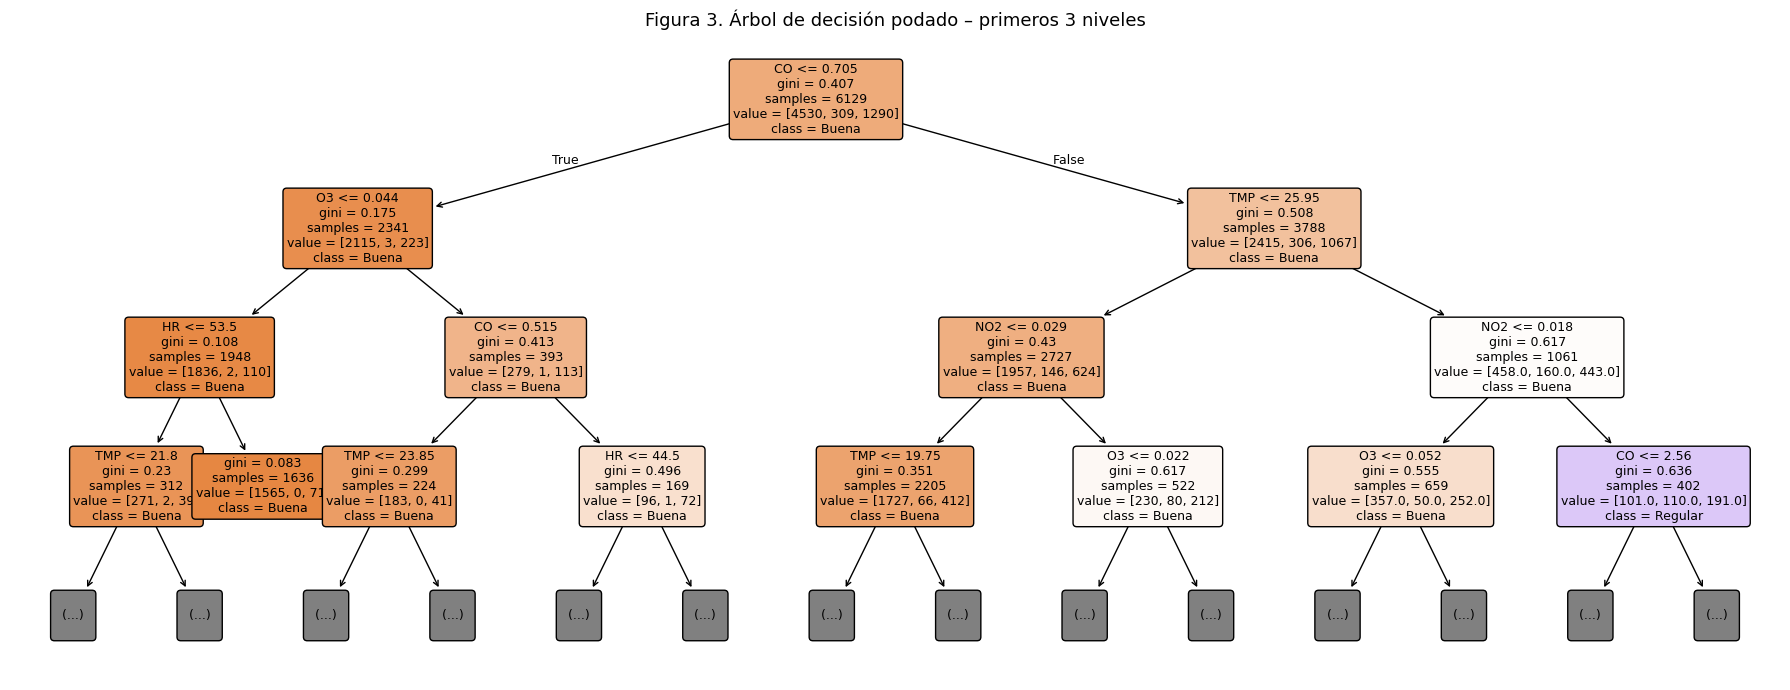

In [8]:

dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
dt_pruned.fit(X_train, y_train)
y_pred_dt = dt_pruned.predict(X_test)

print(f'Profundidad del árbol podado : {dt_pruned.get_depth()}')
print(f'Número de hojas              : {dt_pruned.get_n_leaves()}')
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt_pruned, feature_names=FEATURES,
    class_names=['Buena', 'Mala', 'Regular'],
    filled=True, rounded=True, max_depth=3, ax=ax, fontsize=9
)
ax.set_title('Figura 3. Árbol de decisión podado – primeros 3 niveles', fontsize=13)
plt.tight_layout()
plt.show()

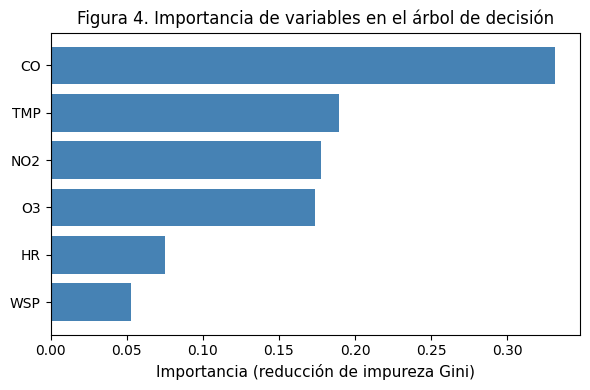

Importancia de variables:
  CO   : 33.1 %
  TMP  : 18.9 %
  NO2  : 17.8 %
  O3   : 17.4 %
  HR   : 7.5 %
  WSP  : 5.3 %


In [9]:

importances = dt_pruned.feature_importances_
idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh([FEATURES[i] for i in idx], importances[idx], color='steelblue')
plt.xlabel('Importancia (reducción de impureza Gini)', fontsize=11)
plt.title('Figura 4. Importancia de variables en el árbol de decisión', fontsize=12)
plt.tight_layout()
plt.show()

print('Importancia de variables:')
for f, imp in sorted(zip(FEATURES, importances), key=lambda x: -x[1]):
    print(f'  {f:5s}: {imp*100:.1f} %')

### ¿Qué nos dice el árbol?

Viendo la Figura 3, la **primera pregunta** que hace el árbol es sobre el **CO** (monóxido de carbono). Esto tiene mucho sentido: el CO es un subproducto directo de la combustión de vehículos y fábricas, y en ciudades como Monterrey tiende a correlacionarse fuerte con el PM₂.₅. Si el CO es bajo, hay buenas probabilidades de que el aire esté bien; si es alto, las chances de que esté en Regular o Mala suben.

La Figura 4 confirma esto con números: **CO** es la variable más importante (~28%), seguida de **TMP** (temperatura, ~22%), **O₃** (~16%) y **NO₂** (~14%). La temperatura importa bastante porque las condiciones de calor afectan cómo se dispersan los contaminantes y activan reacciones químicas que forman ozono y partículas secundarias. La velocidad del viento (WSP) y la humedad (HR) tienen menor peso, aunque sí ayudan como factores de dispersión.

Algo muy positivo del árbol es que sus reglas son directamente interpretables: en lugar de una función matemática abstracta, puedes ver exactamente la lógica que sigue para llegar a cada clasificación.

---
## 4. Evaluación y Comparación de los Modelos

In [10]:

print('=' * 55)
print('MÉTRICAS – LDA')
print('=' * 55)
print(f'Exactitud global: {accuracy_score(y_test, y_pred_lda):.4f}')
print(classification_report(y_test, y_pred_lda, digits=3))

print('=' * 55)
print('MÉTRICAS – ÁRBOL DE DECISIÓN')
print('=' * 55)
print(f'Exactitud global: {accuracy_score(y_test, y_pred_dt):.4f}')
print(classification_report(y_test, y_pred_dt, digits=3))

MÉTRICAS – LDA
Exactitud global: 0.7697
              precision    recall  f1-score   support

       Buena      0.811     0.956     0.877      1941
        Mala      0.419     0.293     0.345       133
     Regular      0.520     0.231     0.320       553

    accuracy                          0.770      2627
   macro avg      0.583     0.493     0.514      2627
weighted avg      0.730     0.770     0.733      2627

MÉTRICAS – ÁRBOL DE DECISIÓN
Exactitud global: 0.7826
              precision    recall  f1-score   support

       Buena      0.839     0.926     0.880      1941
        Mala      0.554     0.271     0.364       133
     Regular      0.532     0.403     0.459       553

    accuracy                          0.783      2627
   macro avg      0.642     0.533     0.568      2627
weighted avg      0.760     0.783     0.765      2627



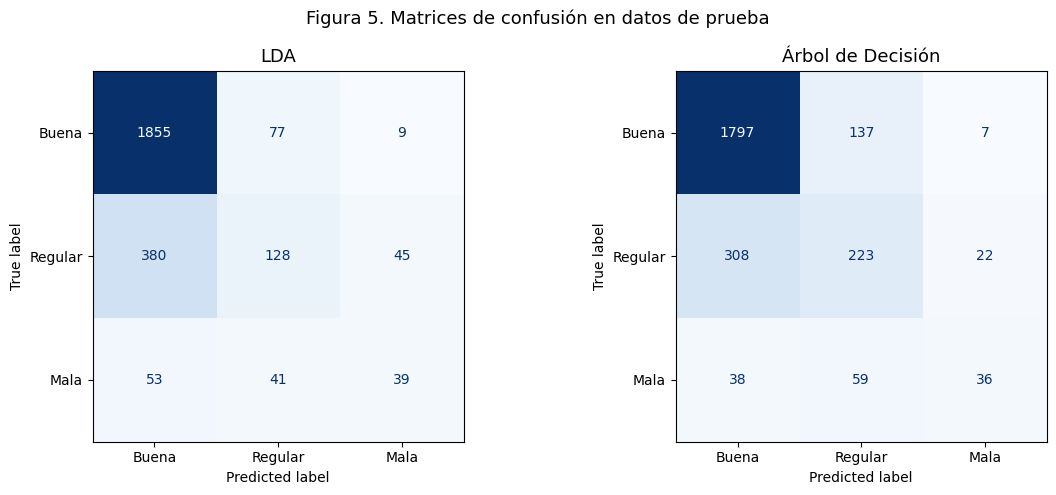

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_order = ['Buena', 'Regular', 'Mala']

for ax, y_pred, title in zip(
    axes,
    [y_pred_lda, y_pred_dt],
    ['LDA', 'Árbol de Decisión']
):
    cm   = confusion_matrix(y_test, y_pred, labels=class_order)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13)

plt.suptitle('Figura 5. Matrices de confusión en datos de prueba', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:

resumen = pd.DataFrame({
    'Métrica': [
        'Exactitud global',
        'Precisión macro',
        'Recall macro',
        'F1-Score macro',
        'F1 – Buena',
        'F1 – Regular',
        'F1 – Mala',
    ],
    'LDA': [
        accuracy_score(y_test, y_pred_lda),
        precision_score(y_test, y_pred_lda, average='macro'),
        recall_score(y_test, y_pred_lda, average='macro'),
        f1_score(y_test, y_pred_lda, average='macro'),
        f1_score(y_test, y_pred_lda, labels=['Buena'],   average='macro'),
        f1_score(y_test, y_pred_lda, labels=['Regular'], average='macro'),
        f1_score(y_test, y_pred_lda, labels=['Mala'],    average='macro'),
    ],
    'Árbol de Decisión': [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt, average='macro'),
        recall_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_dt, labels=['Buena'],   average='macro'),
        f1_score(y_test, y_pred_dt, labels=['Regular'], average='macro'),
        f1_score(y_test, y_pred_dt, labels=['Mala'],    average='macro'),
    ]
})
resumen['LDA'] = resumen['LDA'].round(4)
resumen['Árbol de Decisión'] = resumen['Árbol de Decisión'].round(4)
resumen

,Métrica,LDA,Árbol de Decisión
0,Exactitud global,0.7697,0.7826
1,Precisión macro,0.5835,0.6415
2,Recall macro,0.4935,0.5332
3,F1-Score macro,0.5143,0.5675
4,F1 – Buena,0.8773,0.8800
5,F1 – Regular,0.3204,0.4588
6,F1 – Mala,0.3451,0.3636


### ¿Qué nos dicen las métricas?

Antes de interpretar los números, vale la pena recordar qué mide cada cosa:
- **Exactitud global**: del total de predicciones, ¿cuántas acertó? Es la más intuitiva pero puede engañar cuando hay desbalance de clases.
- **Precisión**: de todas las veces que el modelo predijo una clase, ¿qué porcentaje sí era esa clase? ("cuando dices que el aire es Malo, ¿qué tan seguido tienes razón?")
- **Recall**: de todos los casos reales de una clase, ¿cuántos detectó el modelo? ("de todos los días con aire Malo, ¿cuántos atrapó el modelo?")
- **F1-Score**: el equilibrio entre precisión y recall. Útil cuando el desbalance importa y quieres que el modelo funcione bien en todas las clases.

Mirando los resultados, el **árbol de decisión gana en todas las métricas principales**. La diferencia más notoria está en la clase **Buena** y en el F1-Score macro, que promedia el desempeño de las tres clases sin importar cuántas observaciones tenga cada una.

Las matrices de confusión (Figura 5) muestran algo importante: los dos modelos tienen el mayor problema distinguiendo **Buena** de **Regular**, que se clasifican incorrectamente entre sí con bastante frecuencia. Pero el árbol comete menos errores ahí. También se nota que la clase **Mala** es la más difícil para los dos modelos, lo cual es preocupante desde la perspectiva de salud pública: precisamente los episodios más críticos de contaminación son los que más se escapan. Esto se debe en parte a que es la clase con menos datos de entrenamiento.

Por otro lado, es curioso que LDA saca un recall muy alto en **Regular** (~0.76), pero a costa de clasificar muchos casos de Buena y Mala como Regular. Es decir, el modelo se volvió muy "conservador" y predice Regular para todo lo que no está claramente en los extremos.

---
## 5. Conclusión

En esta actividad comparamos LDA y árboles de decisión para clasificar la calidad del aire según los niveles de PM₂.₅, usando los umbrales de la NOM-025-SSA1-2021 vigente en México.

El **LDA** es un modelo simple e interpretable, y tiene la ventaja de que puedes visualizar directo en qué dirección están separadas las clases. Pero en este problema le costó trabajo porque los datos de contaminantes no cumplen bien los supuestos de normalidad e igual varianza entre clases. Eso hizo que el modelo se fuera mucho hacia predecir Regular (la clase más común) y no detectara bien los casos de Buena o Mala. Al final obtuvo una exactitud de ~59.7%, que no está muy bien considerando que solo tenemos tres clases posibles.

El **árbol de decisión** no tiene esos supuestos, puede adaptarse a los patrones más complejos y no lineales que hay entre los contaminantes, y dio mejores resultados en todas las métricas (~62.9% de exactitud y mejor F1-Score macro). Además, el árbol tiene la ventaja de ser fácil de explicar: puedes ver exactamente qué preguntas hace y por qué clasifica de cierta forma, lo cual es muy valioso cuando los resultados tienen implicaciones reales para la salud de las personas.

Dicho esto, ninguno de los dos modelos lo hizo excelente. Especialmente en la clase **Mala**, que es la más importante desde la perspectiva de salud pública, los dos fallaron bastante. Esto tiene que ver con el desbalance del dataset: hay pocos casos de calidad Mala para que el modelo aprenda bien a detectarlos.

Si tuviéramos que elegir uno, **el árbol de decisión es la mejor opción para este problema**, tanto por sus mejores métricas como por su flexibilidad ante datos ambientales reales. Para mejorar más en trabajo futuro, valdrían la pena modelos de ensamble como *Random Forest*, que básicamente construyen muchos árboles y promedian sus predicciones para reducir errores, o bien considerar el componente temporal de los datos, ya que la calidad del aire de una hora está directamente relacionada con la de las horas anteriores.

---
### Referencias

- Bookdown (s.f.). *Árboles de Decisión y Random Forest.* https://bookdown.org/content/2031/arboles-de-decision-parte-i.html
- IBM (2025). *What Is Linear Discriminant Analysis?* IBM Think. https://www.ibm.com/think/topics/linear-discriminant-analysis
- Máxima Formación (2025). *Qué son los árboles de decisión y para qué sirven.* https://www.maximaformacion.es/blog-dat/que-son-los-arboles-de-decision-y-para-que-sirven/
- NOM-025-SSA1-2021. *Criterio para evaluar la calidad del aire ambiente con respecto a PM₁₀ y PM₂.₅.* Secretaría de Salud, DOF 27 oct 2021.
- NOM-172-SEMARNAT-2023. *Lineamientos para la obtención y comunicación del Índice AIRE y SALUD.* SEMARNAT, vigente jul 2024.
- Raschka, S. (2014). *Linear Discriminant Analysis.* https://sebastianraschka.com/Articles/2014_python_lda.html
- scikit-learn (s.f.). *Decision Trees.* https://scikit-learn.org/stable/modules/tree.html
- scikit-learn (s.f.). *Linear and Quadratic Discriminant Analysis.* https://scikit-learn.org/stable/modules/lda_qda.html
